# Hochschule Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/059vymd37' -- 'Hochschule Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Osnabrück,Fakultät Wirtschafts- und Sozialwissenschaften...,https://openalex.org/W4283577910
1,not assigned,Hochschule Osnabrück,Fakultät Agrarwissenschaften und Landschaftsar...,https://openalex.org/W4283577910
2,not assigned,Hochschule Osnabrück,Osnabr&#x00FC;ck University of Applied Science...,https://openalex.org/W4313562779
3,not assigned,Hochschule Osnabrück,Materials Design and Structural Integrity Labo...,https://openalex.org/W4281641244
4,not assigned,Hochschule Osnabrück,"Faculty for Engineering and Computer Sciences,...",https://openalex.org/W4309457640


In [132]:
MAPPING_DICT = {
    'Department für Duale Studiengänge (DDS)': ['duale studiengänge'],
    'Fakultät Management, Kultur und Technik': ['faculty of management', '(management|kultur) (und|and) (techn(ik|ology)|kultur)'],
    #'Institut für Kommunikationsmanagement': [],
    #'Institut für Theaterpädagogik': [],
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': ['agrarwissenschaften', 'agricultur(e|al)', 'horticultural', 'poultry', 'pflanzenschutz', 'ecology',
                                                                'nutrition', 'plant breeding', 'pflanzenernährung', 'landwirtschaftlich', 'tierhaltung',
                                                                'landtechnik', 'vegetable production', 'livestock farming', 'farm management'
                                                               ],
    'Fakultät Ingenieurwissenschaften und Informatik': ['computer (science|engineering)', 'material(s)? design', 'ingenieurwissenschaften', 'chemistry',
                                                        'verfahrenstechnik', 'thermodynamik', 'plastics', 'production technology'
                                                       ],
    'Fakultät Wirtschafts- und Sozialwissenschaften': ['social (science|studies)', 'sozialwissenschaft(t)?en', 'economic sciences', 'physical therapy',
                                                       'wirtschaftspsychologie', 'informationsmanagement', 'sozialen arbeit', 'political science'
                                                      ],
    #'Forschungszentrum Energiewirtschaft Energierecht (FEE)': [],
    'Forschungszentrum für Gesundheits- und Sozialinformatik': ['health informatics', 'social informatics', 'physiotherap(ie|y)'], # selbst ergänzt
    #'Institut für Musik': [],
    #'Kompetenzzentrum Globale Kompetenz': []
}

In [133]:
with open('./mapping_tables_fak/hsosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [134]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [135]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [136]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,Fakultät Wirtschafts- und Sozialwissenschaften...,https://openalex.org/W4283577910
1,Fakultät Agrarwissenschaften und Landschaftsar...,Hochschule Osnabrück,Fakultät Agrarwissenschaften und Landschaftsar...,https://openalex.org/W4283577910
2,None,Hochschule Osnabrück,Osnabr&#x00FC;ck University of Applied Science...,https://openalex.org/W4313562779
3,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Materials Design and Structural Integrity Labo...,https://openalex.org/W4281641244
4,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty for Engineering and Computer Sciences,...",https://openalex.org/W4309457640
...,...,...,...,...
1107,Fakultät Agrarwissenschaften und Landschaftsar...,Hochschule Osnabrück,"Fachgebiet Integrierter Pflanzenschutz, Hochsc...",https://openalex.org/W3133744627
1108,None,Hochschule Osnabrück,Osnabrück University of Applied Sciences,https://openalex.org/W4407364155
1109,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,Hochschule Osnabrück (University of applied Sc...,https://openalex.org/W4416588562
1110,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,"Hochschule Osnabrück, Abteilung Physiotherapie...",https://openalex.org/W3163914929


In [137]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[20:]

array(['Osnabrück University of Applied Sciences 2 , Osnabrück, Germany',
       'Deutsches Netzwerk für Qualitätsentwicklung in der Pflege (DNQP), Hochschule Osnabrück, Osnabrück, Deutschland',
       'Osnabrück University of Applied Sciences',
       'Hochschule Osnabrück, Germany',
       'University of Applied Sciences  Osnabrück Germany',
       'University of Applied Sciences Osnabrück Germany',
       'University of Applied Sciences Osnabrück',
       'University of Applied Sciences,Osnabr&#x00FC;ck,Germany',
       'Hochschule Osnabrück, University of Applied Sciences, Osnabrück, Germany',
       'Stradiņš University (Latvia), Osnabrück University of Applied Sciences (Germany),',
       'University of Applied Sciences Osnabrück, Albrechtstr. 30, 49076, Osnabrück, Germany',
       'Hochschule Osnabrück Albrechtstr. 30 49076 Osnabrück Deutschland',
       'Hochschule Osnabrck Albrechtstr. 30 49076 Osnabrck Deutschland',
       'University of Applied Science Osnabrueck, Albrechtst

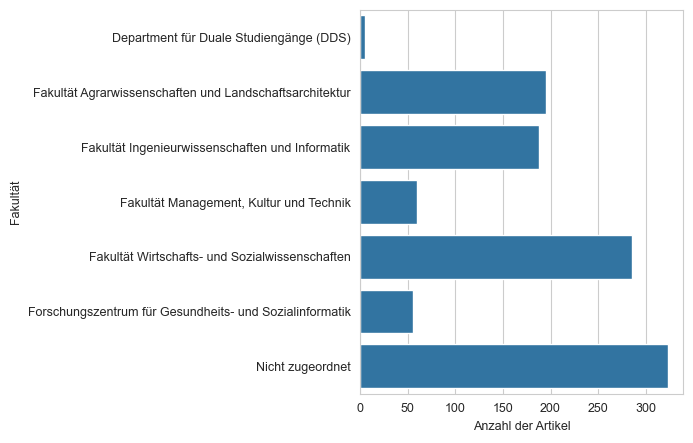

In [138]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [139]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7095323741007195

In [140]:
MAPPING_DICT_DEPT = {
    'Fakultät Management, Kultur und Technik': {},
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': {
        #'Abteilung Stadtplanung und Planungsrecht': [],
        'Bereich Pflanzenernährung und Pflanzenbau': ['plant (nutrition|breeding)'],
        #'Food Engineering - Lebensmitteltechnik': [],
        #'Forschungsschwerpunkt Agrar- und Ernährungssysteme, Landschafts- und Stadtentwicklung': [],
        'Schwerpunkt Precision Livestock Farming': ['livestock'],
    },
    'Fakultät Ingenieurwissenschaften und Informatik': {
        #'Fachbereich Technische Produktentwicklung': [],
        #'Labor Digitale Medien': [],
        'Labor für Angewandte Thermodynamik': ['thermodynami(k|c)'],
        'Labor für anorganische und analytische Chemie': ['chemi(e|stry)'],
        #'Labor für Digital- und Mikroprozessortechnik': [],
        'Labor für Fertigungsmesstechnik und Technisches Management': ['metrology'],
        #'Labor für Mikro- und Optoelektronik': [],
        #'Labor für Nachhaltige Energietechnik': [],
        #'Labor für Umformtechnik und Werkzeugmaschinen': [],
        'Labor für Verfahrenstechnik': ['verfahrenstechnik', 'production technology'],
        #'Laborbereich Fahrzeugtechnik': [],
        'Laborbereich Kunststofftechnik': ['plastics'],
        'Laborbereich Materialdesign und Werkstoffzuverlässigkeit': ['material(s)? design'],
        #'Medienlabor': [],
        #'Professur Konstruktion/CAD und Maschinenelemente': [],
        #'Studiengang Maschinenbau': [],
    },
    'Fakultät Wirtschafts- und Sozialwissenschaften': {}
}

In [141]:
with open('./mapping_tables_dept/hsosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [142]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [143]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät Ingenieurwissenschaften und Informatik')

In [144]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[20:]

array(['Fakultät Ingenieurwissenschaften und Informatik Hochschule Osnabrück Osnabrück Germany',
       'Faculty of Engineering and Computer Science, Osnabrück University of Applied Sciences, Albrechtstr. 30, 49076 Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Material Science and Analysis, University of Applied Sciences Osnabrück, Albrechtstraße 30, 49076 Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Material Science and Analysis, University of Applied Sciences Osnabrück, Albrechtstraße 30, 49076, Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Osnabr&#x00FC;ck University of Applied Sciences, Osnabr&#x00FC;ck, Germany',
       'Faculty of Engineering and Computer Sciences, University of Applied Sciences Osnabrueck, Osnabrueck, Germany',
       'Faculty of Engineering and Computer Science, Osnabrück University of Applied Sciences, 49076, Osnabrück, Germany',
       'Faculty of Engineering and Computer Sci

In [145]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Labor für Angewandte Thermodynamik,1
1,Labor für Fertigungsmesstechnik und Technische...,1
2,Labor für Verfahrenstechnik,5
3,Labor für anorganische und analytische Chemie,14
4,Laborbereich Kunststofftechnik,2
5,Laborbereich Materialdesign und Werkstoffzuver...,33
6,NaN,132


In [146]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
3,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Materials Design and Structural Integrity Labo...,https://openalex.org/W4281641244,Laborbereich Materialdesign und Werkstoffzuver...
4,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty for Engineering and Computer Sciences,...",https://openalex.org/W4309457640,None
8,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, O...",https://openalex.org/W4283260917,None
24,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W4285276525,None
25,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W4285276525,None
...,...,...,...,...,...
1084,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Laboratory for Chemistry and Surface Modificat...,https://openalex.org/W3097368412,Labor für anorganische und analytische Chemie
1095,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W3130855082,None
1097,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Materials Design and Structural Integrity Labo...,https://openalex.org/W3159730684,Laborbereich Materialdesign und Werkstoffzuver...
1098,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Institute of Materials Design and Structural I...,https://openalex.org/W3037948791,Laborbereich Materialdesign und Werkstoffzuver...


In [147]:
MAPPING_DICT_INST = {}

In [148]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Hochschule Osnabrück'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/hsosnabrück.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)